### Attempt to load spike shapes from results

In [41]:
import h5py
import numpy as np
import os

# set working directory to project root
os.chdir("D:\\MasterThesis")
print(os.getcwd())

# define variables 
fileDirectory = "data\\test_data\\"
fileName = 'testdata_results.bxr' # name of BXR file 

#fileDirectory = "data\\excit_data\\"
#fileName = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

chIdx = 282 # identifier of channel to be analysed (282, 739 is good)
wellID = 'Well_A1' # identifier of chip well to be analysed 
 
dataStartPositionSec = 2 # start position in seconds of the portion to extract and plot 
dataDurationSec = 10 # duration in seconds of the portion to extract and plot 
 

# --- open file ---
file = h5py.File(fileDirectory + fileName, 'r')

# --- metadata ---
samplingRate = file.attrs['SamplingRate']
waveformLength = file[wellID + '/SpikeForms'].attrs['Wavelength']

minDigitalValue = file.attrs['MinDigitalValue']
maxDigitalValue = file.attrs['MaxDigitalValue']
minAnalogValue = file.attrs['MinAnalogValue']
maxAnalogValue = file.attrs['MaxAnalogValue']

dacFactor = (maxAnalogValue - minAnalogValue) / (maxDigitalValue - minDigitalValue)
offsetValue = minAnalogValue - dacFactor * minDigitalValue

# --- time window ---
startFrame = int(dataStartPositionSec * samplingRate)
endFrame = int((dataStartPositionSec + dataDurationSec) * samplingRate)

# --- load data ---
spikeTimes = np.array(file[wellID + '/SpikeTimes'])
spikeChIdxs = np.array(file[wellID + '/SpikeChIdxs'])
waveformsFlat = np.array(file[wellID + '/SpikeForms'])

has_units = wellID + '/SpikeUnits' in file
if has_units:
    spikeUnits = np.array(file[wellID + '/SpikeUnits'])

# --- reshape ---
waveformsAll = waveformsFlat.reshape(-1, waveformLength)

# --- filter by time only (ALL channels kept) ---
mask = (
    (spikeTimes >= startFrame) &
    (spikeTimes < endFrame)
)

waveforms = waveformsAll[mask]
channels = spikeChIdxs[mask]

# --- convert to analog ---
waveforms = offsetValue + dacFactor * waveforms

# --- group by channel -> unit ---
result = {}

if has_units:
    units = spikeUnits[mask]

    for ch in np.unique(channels):
        ch_mask = (channels == ch)
        result[ch] = {}

        ch_waveforms = waveforms[ch_mask]
        ch_units = units[ch_mask]

        for u in np.unique(ch_units):
            result[ch][u] = ch_waveforms[ch_units == u]

else:
    for ch in np.unique(channels):
        result[ch] = waveforms[channels == ch]

# --- close file ---
file.close()

D:\MasterThesis


In [2]:
for ch, units in result.items():
    print(f"\nChannel {ch}:")
    
    if isinstance(units, dict):
        for u, wf in units.items():
            print(f"  Unit {u}: {wf.shape}")
    else:
        print(f"  Waveforms: {units.shape}")


Channel 1:
  Unit 0: (1, 50)

Channel 2:
  Unit 1: (5, 50)
  Unit 2: (15, 50)

Channel 3:
  Unit 3: (1, 50)

Channel 9:
  Unit 10: (1, 50)

Channel 12:
  Unit 12: (25, 50)

Channel 15:
  Unit -78: (1, 50)

Channel 28:
  Unit 24: (2, 50)

Channel 31:
  Unit 26: (1, 50)
  Unit 27: (2, 50)

Channel 33:
  Unit 29: (2, 50)

Channel 35:
  Unit 31: (1, 50)

Channel 39:
  Unit 35: (1, 50)

Channel 43:
  Unit 38: (1, 50)

Channel 44:
  Unit 39: (1, 50)

Channel 51:
  Unit 46: (3, 50)

Channel 60:
  Unit 53: (1, 50)

Channel 65:
  Unit 58: (1, 50)

Channel 74:
  Unit 67: (3, 50)

Channel 78:
  Unit 71: (1, 50)

Channel 83:
  Unit 77: (1, 50)

Channel 84:
  Unit 78: (1, 50)

Channel 88:
  Unit 81: (1, 50)

Channel 89:
  Unit 82: (2, 50)
  Unit 83: (3, 50)

Channel 94:
  Unit 88: (1, 50)
  Unit 89: (10, 50)

Channel 95:
  Unit 90: (3, 50)

Channel 96:
  Unit 91: (1, 50)

Channel 97:
  Unit 92: (1, 50)

Channel 104:
  Unit 97: (3, 50)

Channel 107:
  Unit 99: (1, 50)

Channel 110:
  Unit -553: (1,

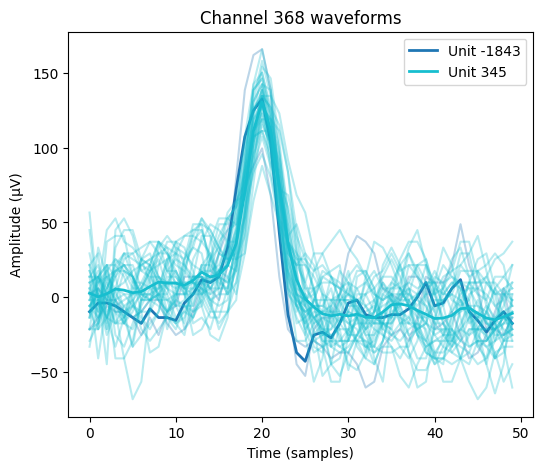

In [24]:
import matplotlib.pyplot as plt
import numpy as np

ch_to_plot = 368  # change to your channel    282, 291, 739 are good

units = result[ch_to_plot]

plt.figure(figsize=(6, 5))

# create one color per unit
colors = plt.cm.tab10(np.linspace(0, 1, len(units)))

for (u, wf), color in zip(units.items(), colors):
    # wf shape: (n_spikes, waveformLength)
    
    for w in wf:
        plt.plot(w, color=color, alpha=0.3)
    
    # optional: plot mean waveform thicker
    mean_wf = wf.mean(axis=0)
    plt.plot(mean_wf, color=color, linewidth=2, label=f"Unit {u}")

plt.title(f"Channel {ch_to_plot} waveforms")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.show()

In [50]:
def align_to_negative_peak(waveforms, target_idx=None):
    """
    Align waveforms so their negative peak (min) is at target_idx.
    Uses circular shift (wrap-around).
    
    waveforms: np.array (n_spikes, waveformLength)
    target_idx: index to align to (default = center)
    """
    n_spikes, L = waveforms.shape
    
    if target_idx is None:
        target_idx = L // 2  # center
    
    aligned = np.zeros_like(waveforms)
    
    for i in range(n_spikes):
        wf = waveforms[i]
        min_idx = np.argmin(wf)
        
        shift = target_idx - min_idx
        
        # circular shift
        aligned[i] = np.roll(wf, shift)
    
    return aligned

In [51]:
aligned = {}

for ch, units in result.items():
    aligned[ch] = {}
    
    for u, wf in units.items():
        aligned[ch][u] = align_to_negative_peak(wf)

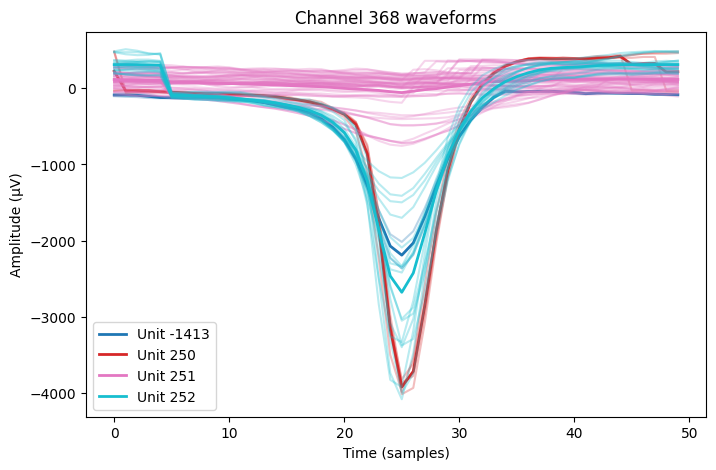

In [93]:
units = aligned[282]  

plt.figure(figsize=(8, 5))

# create one color per unit
colors = plt.cm.tab10(np.linspace(0, 1, len(units)))

for (u, wf), color in zip(units.items(), colors):
    # wf shape: (n_spikes, waveformLength)
    
    for w in wf:
        plt.plot(w, color=color, alpha=0.3)
    
    # optional: plot mean waveform thicker
    mean_wf = wf.mean(axis=0)
    plt.plot(mean_wf, color=color, linewidth=2, label=f"Unit {u}")

plt.title(f"Channel {ch_to_plot} waveforms")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.show()

Alignment creates a lot of mismatch. Maybe let's try to just get rid of the ones that are not aligned. something to mention?

In [34]:
import numpy as np
from sklearn.preprocessing import normalize


def remove_single_waveform_units(data, thresh = 1):
    """
    Remove units that contain only a single waveform.

    data : dict
        Structure: {channel: {unit: waveforms (n_spikes, waveform_length)}}
    """
    cleaned = {}

    for ch, units in data.items():
        if not isinstance(units, dict):
            continue

        new_units = {}

        for u, wf in units.items():
            if wf.shape[0] > thresh:
                new_units[u] = wf

        if new_units:
            cleaned[ch] = new_units

    return cleaned


def enforce_negative_peak(waveforms):
    """
    Ensure all waveforms have a dominant negative peak.
    
    waveforms: (n_spikes, waveformLength)
    """
    corrected = np.copy(waveforms)
    
    for i, wf in enumerate(corrected):
        max_val = np.max(wf)
        min_val = np.min(wf)
        
        # compare absolute amplitudes
        if max_val > abs(min_val):
            corrected[i] = -wf  # invert
    
    return corrected

def filter_by_peak_position(waveforms, min_idx=19, max_idx=21):
    """
    Keep only waveforms whose minimum lies within [min_idx, max_idx]
    
    waveforms: (n_spikes, waveformLength)
    """
    keep = []
    
    for wf in waveforms:
        peak_idx = np.argmin(wf)
        if min_idx <= peak_idx <= max_idx:
            keep.append(wf)
    
    return np.array(keep)

def normalize_waveforms(waveforms, norm='max'):
    """
    Mean-center and normalize each waveform individually.

    waveforms : np.ndarray
        Shape (n_waveforms, waveform_length)
    norm : str
        Normalization type passed to sklearn.preprocessing.normalize

    """

    waveforms = np.asarray(waveforms)

    if waveforms.ndim != 2:
        raise ValueError("Expected input shape (n_waveforms, waveform_length)")

    # 1. remove per-waveform mean
    mean_subtracted = waveforms - np.mean(waveforms, axis=1, keepdims=True)

    # 2. normalize each waveform
    normalized = normalize(mean_subtracted, norm=norm, axis=1)

    return normalized

In [42]:
# Step 1: enforce negative peaks and filter by peak position
filtered = {}

for ch, units in result.items():
    new_units = {}

    for u, wf in units.items():
        wf_processed = enforce_negative_peak(wf)
        wf_processed = filter_by_peak_position(wf_processed, 19, 21)

        if wf_processed.shape[0] > 0:
            new_units[u] = wf_processed

    if new_units:
        filtered[ch] = new_units

# Step 2: remove weak units first
cleaned_filtered = remove_single_waveform_units(filtered, thresh=20)

# Step 3: normalize waveforms
normalized_data = {}

for ch, units in cleaned_filtered.items():
    new_units = {}

    for u, wf in units.items():
        wf_norm = normalize_waveforms(wf)

        # optional: skip empty results (rare but safe)
        if wf_norm.shape[0] > 0:
            new_units[u] = wf_norm

    if new_units:
        normalized_data[ch] = new_units


In [27]:
ch_to_plot = 282  # change to your channel    282, 291, 739 are good
units = normalized_data[ch_to_plot]

plt.figure(figsize=(8, 5))

# create one color per unit
colors = plt.cm.tab10(np.linspace(0, 1, len(units)))

for (u, wf), color in zip(units.items(), colors):
    # wf shape: (n_spikes, waveformLength)
    
    for w in wf:
        plt.plot(w, color=color, alpha=0.3)
    
    # optional: plot mean waveform thicker
    mean_wf = wf.mean(axis=0)
    plt.plot(mean_wf, color=color, linewidth=2, label=f"Unit {u}")

plt.title(f"Channel {ch_to_plot} waveforms")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.show()

KeyError: 282

Unit 282: Is it possible at all that this might be a deflection from a large number of cells? \
Unit 291: What is the criterion for flipping or not? \
Units 125, 126, 127: Are these all the same one? \
Unit 368 vs 126: Some are super clear while some are more messy \
Unit 2539: Oversplitting of can we assume that slightly different shape?


In [114]:
for ch, units in cleaned_filtered.items():
    print(f"\nChannel {ch}:")
    
    if isinstance(units, dict):
        for u, wf in units.items():
            print(f"  Unit {u}: {wf.shape}")
    else:
        print(f"  Waveforms: {units.shape}")


Channel 12:
  Unit 12: (25, 50)

Channel 110:
  Unit 101: (47, 50)

Channel 125:
  Unit 113: (47, 50)

Channel 126:
  Unit 114: (41, 50)

Channel 127:
  Unit 118: (41, 50)

Channel 171:
  Unit 152: (41, 50)

Channel 190:
  Unit 167: (49, 50)

Channel 235:
  Unit 209: (39, 50)

Channel 291:
  Unit 260: (40, 50)

Channel 306:
  Unit 273: (41, 50)

Channel 355:
  Unit 332: (32, 50)

Channel 361:
  Unit 338: (26, 50)

Channel 368:
  Unit 345: (36, 50)

Channel 430:
  Unit 402: (27, 50)

Channel 433:
  Unit 405: (41, 50)

Channel 512:
  Unit 476: (47, 50)
  Unit 477: (41, 50)

Channel 539:
  Unit 505: (40, 50)

Channel 554:
  Unit 525: (26, 50)

Channel 555:
  Unit 527: (21, 50)

Channel 556:
  Unit 530: (28, 50)

Channel 571:
  Unit 545: (22, 50)

Channel 599:
  Unit 567: (25, 50)

Channel 619:
  Unit 586: (37, 50)
  Unit 587: (46, 50)

Channel 620:
  Unit 588: (29, 50)

Channel 659:
  Unit 623: (21, 50)

Channel 691:
  Unit 651: (30, 50)
  Unit 652: (32, 50)

Channel 723:
  Unit 682: (25

In [115]:
print(minAnalogValue, maxAnalogValue)
print(waveforms.min(), waveforms.max())

-8000.0 8000.0
-4084.9816849816852 2940.1709401709395


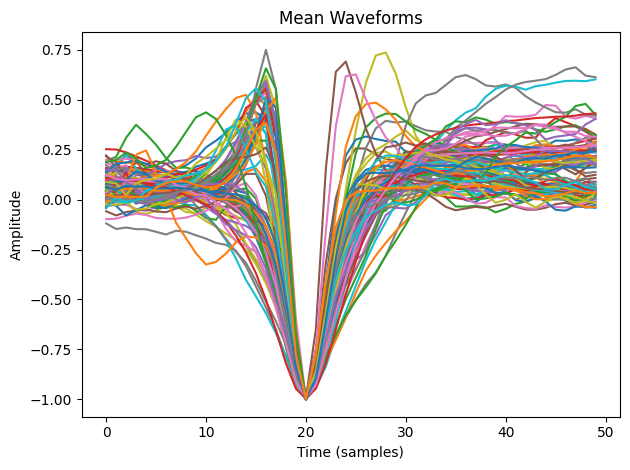

In [43]:
# Plots for everything

def plot_mean_waveforms(data, max_units_per_channel=None):
    """
    Plot mean waveform per unit for each channel.

    data : dict
        {channel: {unit: (n_spikes, waveform_length)}}
    max_units_per_channel : int or None
        Limit number of units plotted per channel (for readability)
    """

    plt.figure()

    for ch, units in data.items():

        plotted = 0

        for u, wf in units.items():

            mean_wf = np.mean(wf, axis=0)

            plt.plot(mean_wf, label=f"Unit {u}")

            plotted += 1
            if max_units_per_channel and plotted >= max_units_per_channel:
                break

    plt.title(f"Mean Waveforms")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


plot_mean_waveforms(normalized_data)

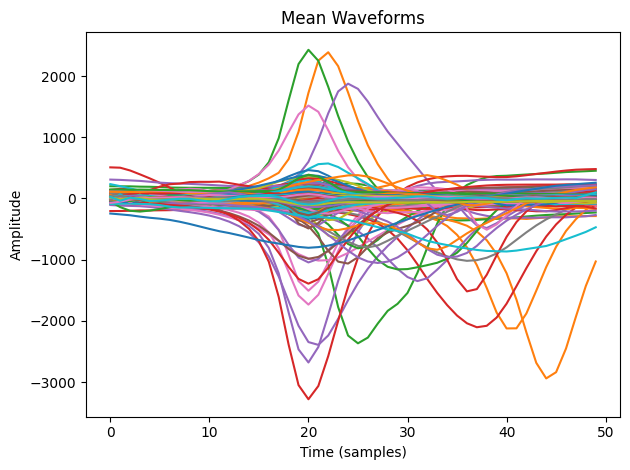

In [44]:
plot_mean_waveforms(result)

In [38]:
import numpy as np
import pandas as pd

def export_mean_waveforms_to_csv(data, filename="mean_waveforms.csv"):
    """
    Export mean waveform of each unit to CSV.
    
    Each row = one mean waveform
    Each column = one waveform sample point
    """

    rows = []

    for ch, units in data.items():

        for u, wf in units.items():

            mean_wf = np.mean(wf, axis=0)

            rows.append(mean_wf)

    df = pd.DataFrame(rows)

    df.to_csv(filename, index=False, header=False)

    print(f"Saved {len(df)} mean waveforms to: {filename}")

    return df

In [45]:
df_mean_waveforms = export_mean_waveforms_to_csv(
    normalized_data,
    "mean_waveforms_preprocessed.csv"
)

Saved 92 mean waveforms to: mean_waveforms_preprocessed.csv
